### ML Forecast benchmarking for GPU Utilization 

#### No exogeneous variables 

In [1]:
import pandas as pd

In [2]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

In [3]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [19]:
import polars as pl
import numpy as np
from utilsforecast.losses import mae, rmse, mse, mape, smape

In [4]:
Y_df = pd.read_csv('gpu_slurm_metrics_10s_cleaned.csv') # load the data
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259185 entries, 0 to 1259184
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   timestamp               1259185 non-null  object 
 1   gpu_index               1259185 non-null  int64  
 2   utilization_gpu_pct     1259185 non-null  float64
 3   utilization_memory_pct  1259185 non-null  float64
 4   temperature_gpu         1259185 non-null  float64
 5   temperature_memory      1259185 non-null  float64
 6   power_draw_W            1259185 non-null  float64
 7   id_job                  1259185 non-null  int64  
 8   time_start              1259185 non-null  float64
 9   time_end                1259185 non-null  float64
dtypes: float64(7), int64(2), object(1)
memory usage: 96.1+ MB


In [5]:
Y_df['unique_id'] = Y_df['id_job'].astype(str) + '_gpu' + Y_df['gpu_index'].astype(str)

In [6]:
Y_df['timestamp'] = pd.to_datetime(Y_df['timestamp'])
Y_df = Y_df.sort_values(by=['unique_id', 'timestamp'])

In [7]:
Y_df['y'] = Y_df['utilization_gpu_pct']

In [8]:
Y_df['ds'] = Y_df.groupby('unique_id').cumcount()

In [9]:
# This is the standard format for Nixtla.
prepared_df = Y_df[['unique_id', 'ds', 'y']]

print("Data prepared successfully. Head of the DataFrame:")
print(prepared_df.head())
print(f"\nNumber of unique time series (job-gpu combinations): {prepared_df['unique_id'].nunique()}")

Data prepared successfully. Head of the DataFrame:
                  unique_id  ds         y
264388  10217518336509_gpu0   0  6.360656
471025  10217518336509_gpu0   1  0.435484
264389  10217518336509_gpu0   2  0.031915
471026  10217518336509_gpu0   3  0.063830
264390  10217518336509_gpu0   4  1.150538

Number of unique time series (job-gpu combinations): 414


In [10]:
prepared_df.count()

unique_id    1259185
ds           1259185
y            1259185
dtype: int64

In [12]:
# pick a reference start time
start_time = pd.Timestamp("2023-01-01 00:00:00")

# convert ds (integer steps) into datetime
prepared_df['ds'] = pd.to_timedelta(prepared_df['ds'] * 10, unit='s') + start_time

/tmp/ipykernel_12820/2362352151.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prepared_df['ds'] = pd.to_timedelta(prepared_df['ds'] * 10, unit='s') + start_time


In [13]:
if isinstance(prepared_df, list):
    prepared_df = pd.DataFrame(prepared_df)

# Ensure required columns exist
print(prepared_df.dtypes)
print(prepared_df.tail())

unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object
                 unique_id                  ds          y
463470  9976590120891_gpu1 2023-01-02 16:20:50  96.072289
463471  9976590120891_gpu1 2023-01-02 16:21:00  97.168675
463472  9976590120891_gpu1 2023-01-02 16:21:10  96.626506
463473  9976590120891_gpu1 2023-01-02 16:21:20  98.867470
463474  9976590120891_gpu1 2023-01-02 16:21:30  54.137931


In [14]:
prepared_df.dtypes

unique_id            object
ds           datetime64[ns]
y                   float64
dtype: object

In [15]:
# Define models
models = [
    XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    ),
    LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
]


#### Cross validation of MLForecast models with different lags 

In [16]:

# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    num_threads=-1,  # Use all available cores

)

# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=prepared_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
)


/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/mlforecast/core.py:185: UserWarning: Setting num_threads to 1.
  warnings.warn("Setting num_threads to 1.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 35
[LightGBM] [Info] Start training from score 94.627718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 35
[LightGBM] [Info] Start training from score 94.625601
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 998365, number of used features: 35
[LightGBM] [Info] Star

In [17]:
cv_df.head()

,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,94.702128,94.404480,94.326372
1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,94.457447,94.710014,94.675869
2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,94.677419,94.365013,94.274524
3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,94.645161,94.715332,94.681897
4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,94.516129,94.235008,94.149833


In [46]:
cv_df.to_csv("mlforecast_results.csv")

In [2]:
cv_df = pd.read_csv("mlforecast_results.csv")

In [20]:
def evaluate_forecast(df, y_col="y", id_col="unique_id", ds_col="ds"):
    # Detect all forecast model columns (exclude id, ds, y)
    model_cols = [c for c in df.columns if c not in [id_col, ds_col, y_col, "Unnamed: 0", "cutoff"]]
    
    # Convert pandas → polars
    pl_df = pl.from_pandas(df[[id_col, y_col] + model_cols])
    
    # -----------------
    # Per-series metrics
    # -----------------
    results = {
        "MAE": mae(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "RMSE": rmse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MSE": mse(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "MAPE": mape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
        "sMAPE": smape(pl_df, models=model_cols, id_col=id_col, target_col=y_col),
    }
    
    metrics_df = None
    for name, metric in results.items():
        metric = metric.rename({c: f"{c}_{name}" for c in metric.columns if c != id_col})
        metrics_df = metric if metrics_df is None else metrics_df.join(metric, on=id_col, how="inner")
    per_series_metrics = metrics_df.to_pandas()
    
    # -----------------
    # Global metrics
    # -----------------
    global_results = []
    y_true = df[y_col].values
    
    for model in model_cols:
        y_pred = df[model].values
        global_results.append({
            "Model": model,
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MSE": np.mean((y_true - y_pred) ** 2),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
            "sMAPE": np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))),
            "wMAPE": np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100,
        })
    
    global_metrics = pd.DataFrame(global_results)
    
    return per_series_metrics, global_metrics



In [21]:
### Results for MLForecast with lags only 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)


Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0          0.754570           0.777780   
1  10217518336509_gpu1          0.717045           0.749189   
2  10297115157410_gpu1          0.399828           0.394113   
3  10612452483078_gpu0          0.701597           0.687796   
4  10612452483078_gpu1          0.473664           0.482783   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0           3.274303            3.267076         10.721057          10.673786   
1           3.532595            3.520730         12.479229          12.395541   
2           2.046089            2.053018          4.186480           4.214883   
3           3.309390            3.312027         10.952060          10.969522   
4           3.078983            3.080529          9.480134           9.489659   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.009509            0.009748         

/tmp/ipykernel_12820/946279443.py:38: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


#### Feature importance 

In [37]:
# Define models
models = [
    XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    ),
    LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
]

# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    num_threads=-1,  # Use all available cores

)

/project/home/p200631/conda_base_path/miniconda3/envs/spark-env/lib/python3.11/site-packages/mlforecast/core.py:185: UserWarning: Setting num_threads to 1.
  warnings.warn("Setting num_threads to 1.")


In [43]:
mlf.fit(prepared_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8925
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 35
[LightGBM] [Info] Start training from score 94.614314


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600'], date_features=[], num_threads=1)

In [46]:
mlf

MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600'], date_features=[], num_threads=1)

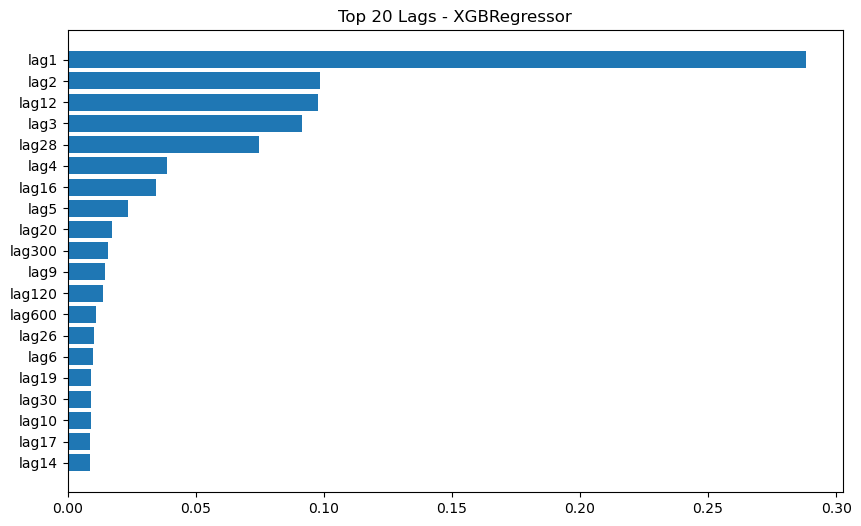

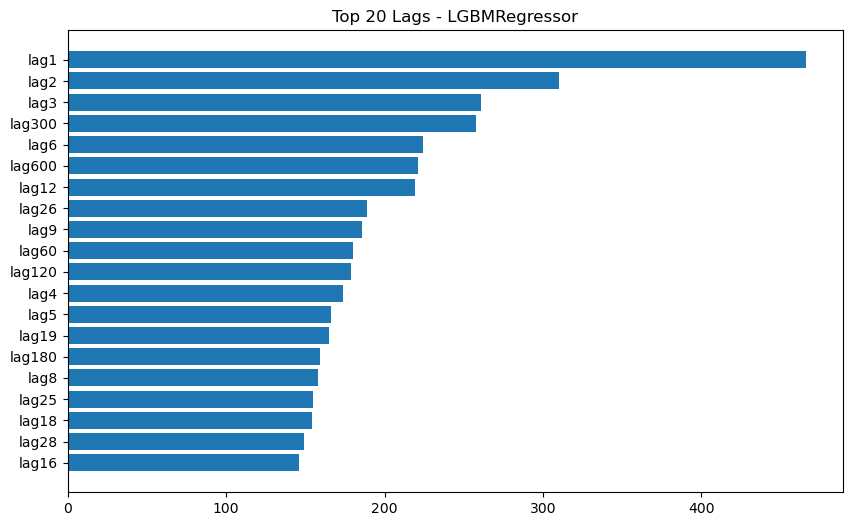

In [62]:
import matplotlib.pyplot as plt

fi_all = []

for model in mlf.models:  # model objects in your MLForecast
    trained_model = mlf.models_[model]  # directly the trained regressor
    
    # feature names
    if hasattr(trained_model, 'get_booster'):  # XGBRegressor
        feature_names = trained_model.get_booster().feature_names
    else:  # LGBMRegressor
        feature_names = trained_model.feature_name_
    
    # feature importance
    importance = trained_model.feature_importances_
    
    fi_df = pd.DataFrame({
        'model': model,
        'feature': feature_names,
        'importance': importance
    })
    
    fi_all.append(fi_df)

# Combine all models
fi_df = pd.concat(fi_all, ignore_index=True)

# Plot top 20 features per model
for model_name in fi_df['model'].unique():
    df_model = fi_df[fi_df['model'] == model_name].sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(10,6))
    plt.barh(df_model['feature'][::-1], df_model['importance'][::-1])
    plt.title(f'Top 20 Lags - {model_name}')
    plt.show()


In [23]:
def plot_top_lags(mlf, top_n=20):
    """
    Plot top lags/features for XGB and LGBM models in an MLForecast object.
    
    Parameters:
    -----------
    mlf : MLForecast
        Fitted MLForecast object.
    top_n : int
        Number of top features to display per model.
    """
    fi_all = []

    for model_obj in mlf.models:
        trained = mlf.models_[model_obj]
        
        # Check if multiple series
        if isinstance(trained, dict):  # multiple unique_id series
            for series_id, tm in trained.items():
                if hasattr(tm, 'get_booster'):  # XGBRegressor
                    feature_names = tm.get_booster().feature_names
                else:  # LGBMRegressor
                    feature_names = tm.feature_name_
                
                importance = tm.feature_importances_
                
                fi_all.append(pd.DataFrame({
                    'model': model_obj,
                    'series_id': series_id,
                    'feature': feature_names,
                    'importance': importance
                }))
        else:  # single series
            tm = trained
            if hasattr(tm, 'get_booster'):  # XGBRegressor
                feature_names = tm.get_booster().feature_names
            else:  # LGBMRegressor
                feature_names = tm.feature_name_
            
            importance = tm.feature_importances_
            
            fi_all.append(pd.DataFrame({
                'model': model_obj,
                'series_id': None,
                'feature': feature_names,
                'importance': importance
            }))
    
    # Combine all models/series
    fi_df = pd.concat(fi_all, ignore_index=True)
    
    # Aggregate importance across series if multiple
    fi_mean = fi_df.groupby(['model','feature'])['importance'].mean().reset_index()
    
    # Plot top features per model
    for model_name in fi_mean['model'].unique():
        df_model = fi_mean[fi_mean['model'] == model_name].sort_values('importance', ascending=False).head(top_n)
        
        plt.figure(figsize=(10,6))
        plt.barh(df_model['feature'][::-1], df_model['importance'][::-1])
        plt.title(f'Top {top_n} Lags / Features - {model_name}')
        plt.xlabel('Importance')
        plt.show()


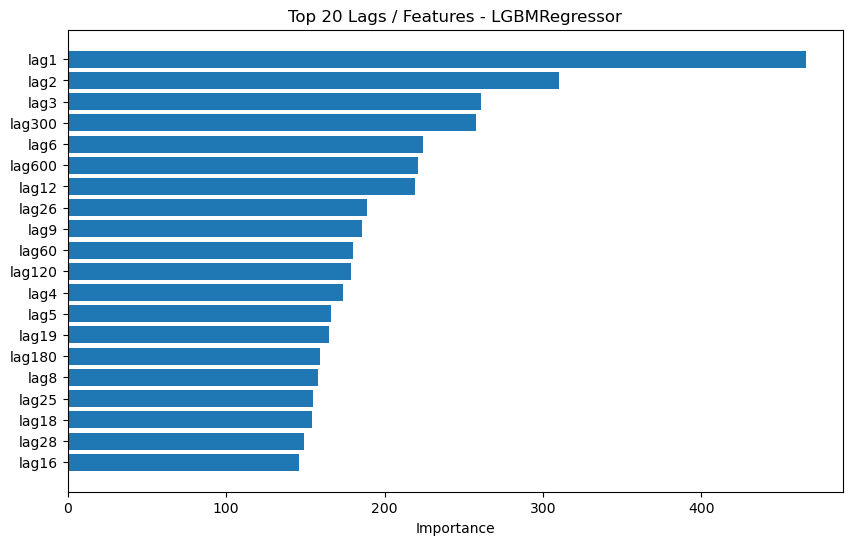

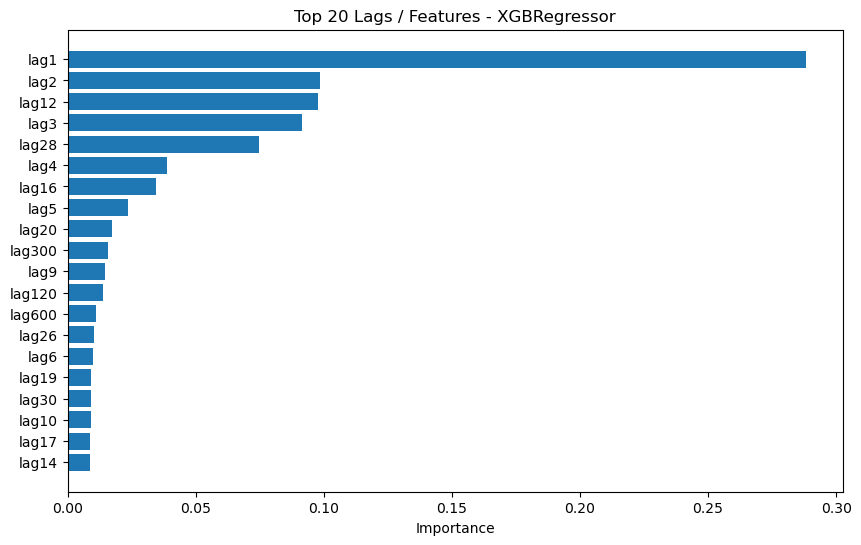

In [66]:
plot_top_lags(mlf, top_n=20)

In [67]:
#Adding rolling mean and expanding mean to lags 

In [22]:
from mlforecast.lag_transforms import RollingMean, ExpandingStd

In [23]:
# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq="10s",  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    lag_transforms={
        1: [ExpandingStd()],
        2: [RollingMean(window_size=3, min_samples=1), RollingMean(window_size=6)]
    },
)

In [24]:
# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=prepared_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030964 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 38
[LightGBM] [Info] Start training from score 94.627718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 38
[LightGBM] [Info] Start training from score 94.625601
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 998365, number of used features: 38
[LightGBM] [Info] Star

In [26]:
cv_df.head()

,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,94.702128,94.384903,94.242316
1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,94.457447,94.681419,94.662047
2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,94.677419,94.425941,94.288321
3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,94.645161,94.672325,94.592049
4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,94.516129,94.322708,94.167277


In [25]:
### Results for MLForecast with lag transforms 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)

Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0          0.737553           0.766561   
1  10217518336509_gpu1          0.706151           0.709090   
2  10297115157410_gpu1          0.409958           0.397338   
3  10612452483078_gpu0          0.728625           0.711176   
4  10612452483078_gpu1          0.477334           0.485550   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0           3.271457            3.260184         10.702432          10.628799   
1           3.543019            3.535839         12.552983          12.502159   
2           2.043228            2.045144          4.174782           4.182613   
3           3.309902            3.309689         10.955450          10.954044   
4           3.077839            3.079394          9.473090           9.482670   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.009329            0.009627         

/tmp/ipykernel_12820/946279443.py:38: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


In [75]:
mlf.fit(prepared_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9690
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 38
[LightGBM] [Info] Start training from score 94.614314


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=10s, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600', 'expanding_std_lag1', 'rolling_mean_lag2_window_size3_min_samples1', 'rolling_mean_lag2_window_size6'], date_features=[], num_threads=1)

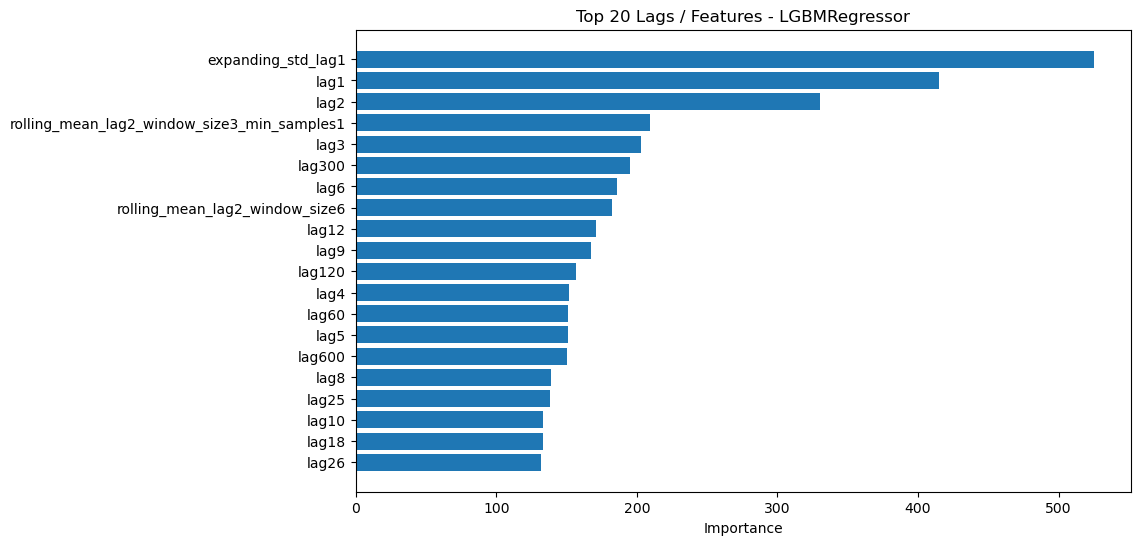

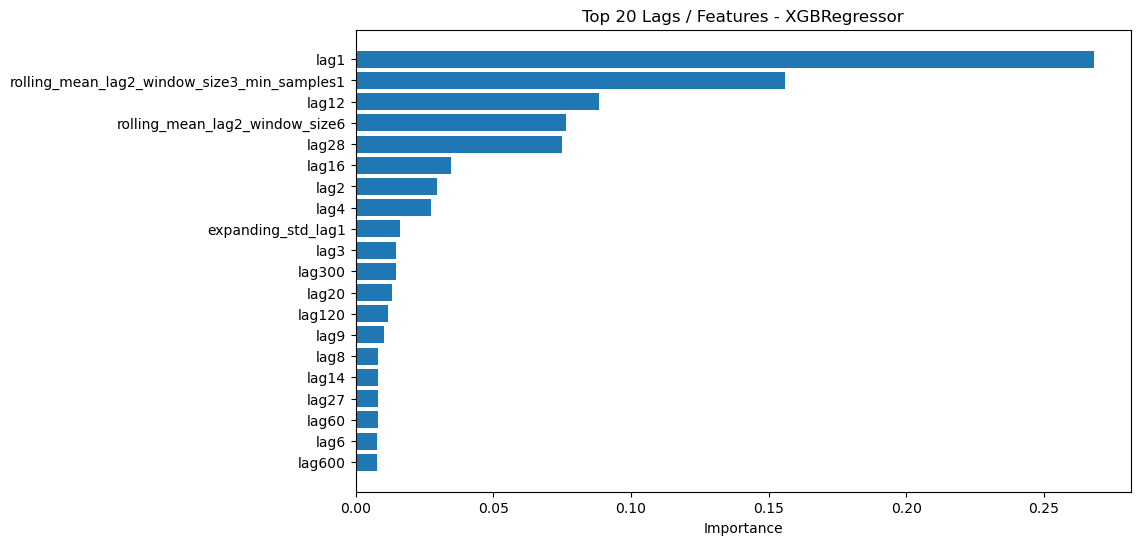

In [76]:
plot_top_lags(mlf, top_n=20)

### Predictions compared to real values plotting 

In [51]:
cv_df.head()

,Unnamed: 0,unique_id,ds,cutoff,y,XGBRegressor,LGBMRegressor
0,0,10217518336509_gpu0,2023-01-01 13:51:20,2023-01-01 13:51:10,94.702128,94.404480,94.326372
1,1,10217518336509_gpu0,2023-01-01 13:51:30,2023-01-01 13:51:10,94.457447,94.710014,94.675869
2,2,10217518336509_gpu0,2023-01-01 13:51:40,2023-01-01 13:51:10,94.677419,94.365010,94.274524
3,3,10217518336509_gpu0,2023-01-01 13:51:50,2023-01-01 13:51:10,94.645161,94.715330,94.681897
4,4,10217518336509_gpu0,2023-01-01 13:52:00,2023-01-01 13:51:10,94.516129,94.235010,94.149833


In [52]:
from statsforecast import StatsForecast

In [53]:
fcst_no_e = cv_df[["unique_id", "ds", "XGBRegressor", "LGBMRegressor"]]

In [57]:
test_df = cv_df[["unique_id", "ds", "y"]]

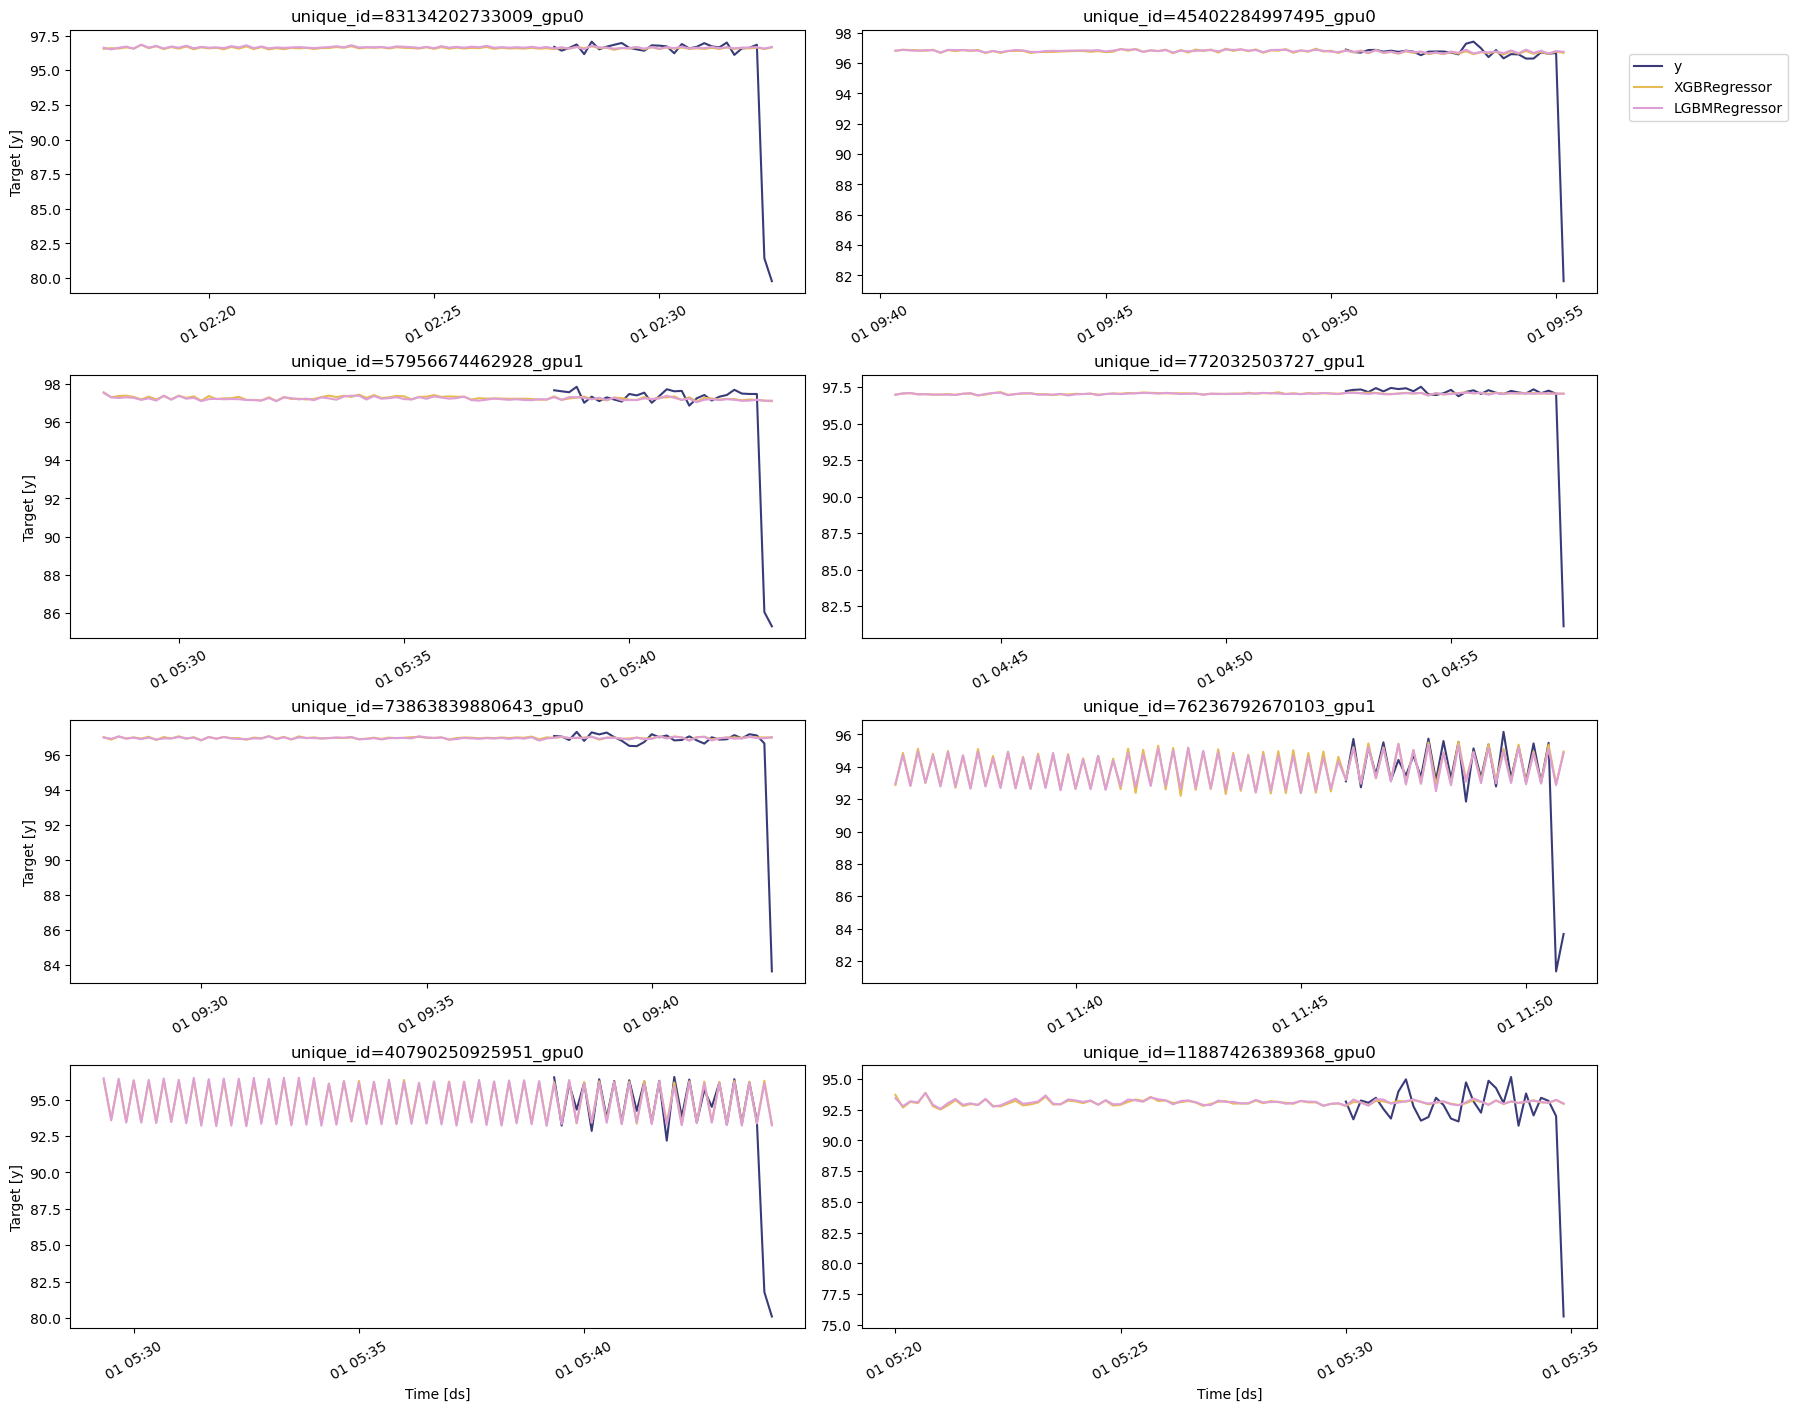

In [59]:
StatsForecast.plot(test_df, fcst_no_e, max_insample_length=30)

#### With exogeneous values

In [27]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259185 entries, 264388 to 463474
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   timestamp               1259185 non-null  datetime64[ns]
 1   gpu_index               1259185 non-null  int64         
 2   utilization_gpu_pct     1259185 non-null  float64       
 3   utilization_memory_pct  1259185 non-null  float64       
 4   temperature_gpu         1259185 non-null  float64       
 5   temperature_memory      1259185 non-null  float64       
 6   power_draw_W            1259185 non-null  float64       
 7   id_job                  1259185 non-null  int64         
 8   time_start              1259185 non-null  float64       
 9   time_end                1259185 non-null  float64       
 10  unique_id               1259185 non-null  object        
 11  y                       1259185 non-null  float64       
 12  ds             

In [28]:
Y_df.drop(['utilization_gpu_pct', 'timestamp', 'gpu_index', 'id_job' , 'time_start', 'time_end'], axis =1, inplace=True)

In [29]:
# Setup MLForecast
mlf = MLForecast(
    models=models,
    freq=1,  # step index (10s)
    # target_transforms=[None, Differences([1])],   # difference transform for stationarity
    lags=list(range(1, 31)) + [60, 120, 180, 300, 600],  # short + medium + long lags
    lag_transforms={
        1: [ExpandingStd()],
        2: [RollingMean(window_size=3, min_samples=1), RollingMean(window_size=6)]
    },
)

In [31]:
# Run cross-validation
# h=30 → horizon = 5 minutes (10s x 30)
# n_windows → number of rolling origin evaluations (try 3–5)
cv_df = mlf.cross_validation(
    df=Y_df,   # your dataset with [unique_id, ds, y, exogenous...]
    h=30,
    n_windows=3,
    static_features=[],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 973525, number of used features: 42
[LightGBM] [Info] Start training from score 94.627718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 985945, number of used features: 42
[LightGBM] [Info] Start training from score 94.625601
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 998365, number of used features: 42
[LightGBM] [Info] S

In [32]:
### Results for MLForecast with exogeneous variables and lag transforms 
per_series_metrics, global_metrics = evaluate_forecast(cv_df)

print("Per-series metrics:\n", per_series_metrics.head())
print("\nGlobal metrics:\n", global_metrics)

Per-series metrics:
              unique_id  XGBRegressor_MAE  LGBMRegressor_MAE  \
0  10217518336509_gpu0         10.459013           6.625656   
1  10217518336509_gpu1          8.652447           1.744392   
2  10297115157410_gpu1          0.217015           0.214669   
3  10612452483078_gpu0          0.314809           0.237276   
4  10612452483078_gpu1          0.272962           0.284682   

   XGBRegressor_RMSE  LGBMRegressor_RMSE  XGBRegressor_MSE  LGBMRegressor_MSE  \
0          12.352931            9.155930        152.594900          83.831060   
1          11.208836            3.943774        125.638007          15.553352   
2           0.397236            0.414273          0.157797           0.171622   
3           1.103496            0.594002          1.217704           0.352838   
4           1.010008            1.019258          1.020117           1.038886   

   XGBRegressor_MAPE  LGBMRegressor_MAPE  XGBRegressor_sMAPE  \
0           0.111535            0.070655         

/tmp/ipykernel_12820/946279443.py:38: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


In [21]:
mlf.fit(Y_df, static_features=[])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 1010785, number of used features: 42
[LightGBM] [Info] Start training from score 94.614314


MLForecast(models=[XGBRegressor, LGBMRegressor], freq=1, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21', 'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28', 'lag29', 'lag30', 'lag60', 'lag120', 'lag180', 'lag300', 'lag600', 'expanding_std_lag1', 'rolling_mean_lag2_window_size3_min_samples1', 'rolling_mean_lag2_window_size6'], date_features=[], num_threads=1)

In [22]:
mlf.ts.features_order_



['utilization_memory_pct',
 'temperature_gpu',
 'temperature_memory',
 'power_draw_W',
 'lag1',
 'lag2',
 'lag3',
 'lag4',
 'lag5',
 'lag6',
 'lag7',
 'lag8',
 'lag9',
 'lag10',
 'lag11',
 'lag12',
 'lag13',
 'lag14',
 'lag15',
 'lag16',
 'lag17',
 'lag18',
 'lag19',
 'lag20',
 'lag21',
 'lag22',
 'lag23',
 'lag24',
 'lag25',
 'lag26',
 'lag27',
 'lag28',
 'lag29',
 'lag30',
 'lag60',
 'lag120',
 'lag180',
 'lag300',
 'lag600',
 'expanding_std_lag1',
 'rolling_mean_lag2_window_size3_min_samples1',
 'rolling_mean_lag2_window_size6']

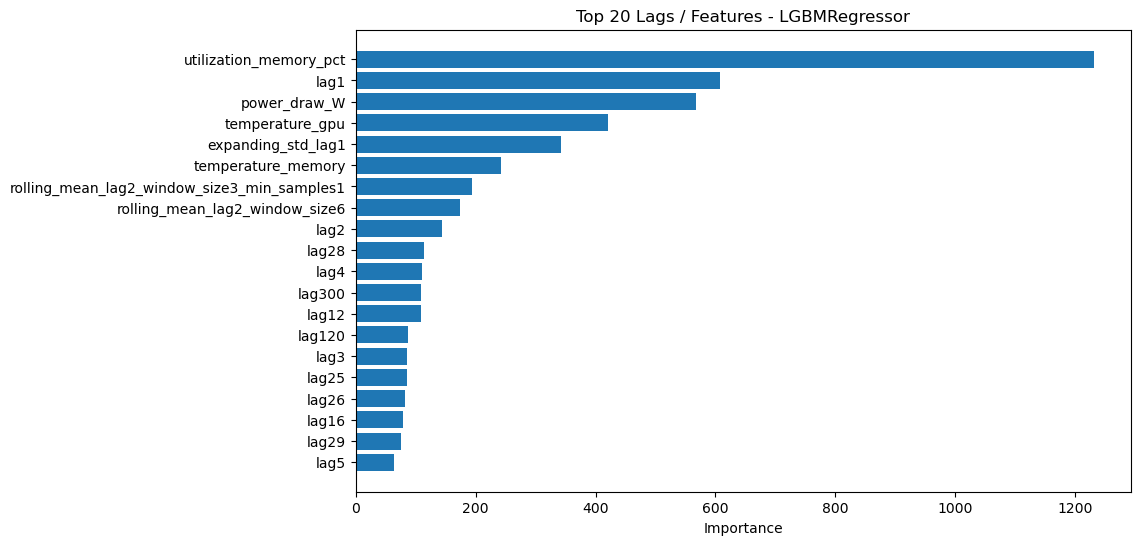

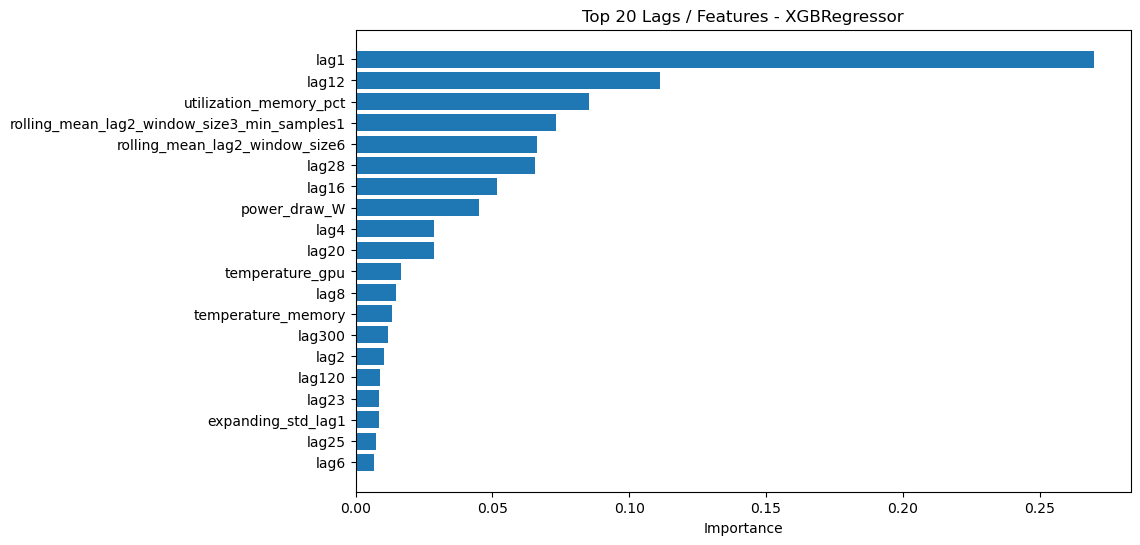

In [25]:
plot_top_lags(mlf, top_n=20)

In [35]:
Y_df.head()

,utilization_memory_pct,temperature_gpu,temperature_memory,power_draw_W,unique_id,y,ds
264388,0.360656,65.180328,66.393443,54.939016,10217518336509_gpu0,6.360656,0
471025,0.000000,40.000000,38.080645,46.433710,10217518336509_gpu0,0.435484,1
264389,0.010638,63.638298,64.861702,53.556915,10217518336509_gpu0,0.031915,2
471026,0.021277,40.000000,38.042553,46.569681,10217518336509_gpu0,0.063830,3
264390,0.032258,62.311828,63.387097,52.611935,10217518336509_gpu0,1.150538,4
